In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
#import other model for naive, knn, logistic regression
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

In [2]:
# split from preprocessed data

df = pd.read_csv('../data/preprocessed_result_260304_01.csv')
X = df['tweet']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vectorize the text data using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


Naive Bayes Classification Report:
              precision    recall  f1-score   support

   Non-Toxic       0.94      0.86      0.90      7622
       Toxic       0.87      0.94      0.91      7608

    accuracy                           0.90     15230
   macro avg       0.91      0.90      0.90     15230
weighted avg       0.91      0.90      0.90     15230



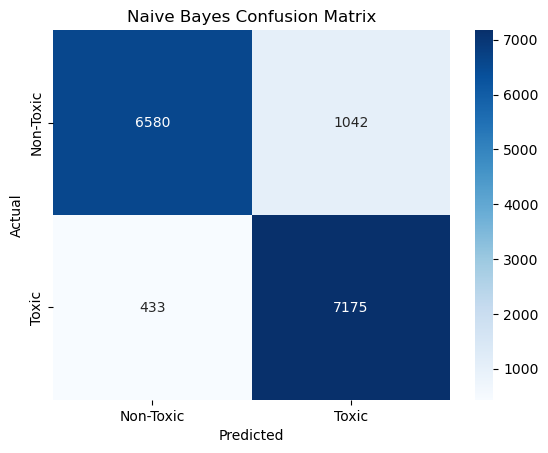


KNN Classification Report:
              precision    recall  f1-score   support

   Non-Toxic       0.71      0.94      0.81      7622
       Toxic       0.90      0.62      0.73      7608

    accuracy                           0.78     15230
   macro avg       0.81      0.78      0.77     15230
weighted avg       0.81      0.78      0.77     15230



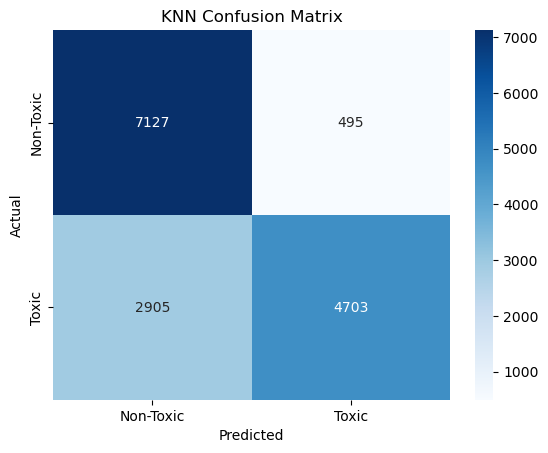


SVM Classification Report:
              precision    recall  f1-score   support

   Non-Toxic       0.94      0.96      0.95      7622
       Toxic       0.96      0.94      0.95      7608

    accuracy                           0.95     15230
   macro avg       0.95      0.95      0.95     15230
weighted avg       0.95      0.95      0.95     15230



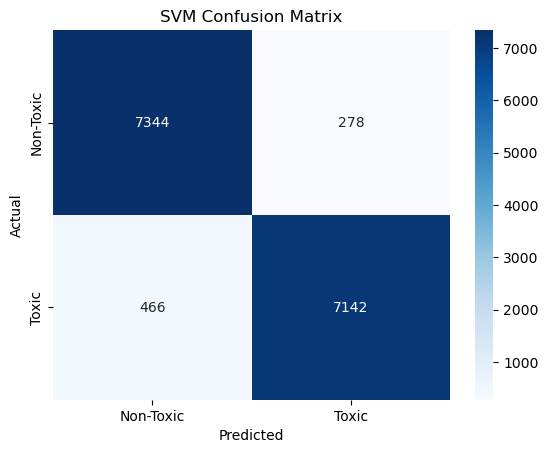


Logistic Regression Classification Report:
              precision    recall  f1-score   support

   Non-Toxic       0.93      0.97      0.95      7622
       Toxic       0.97      0.92      0.94      7608

    accuracy                           0.95     15230
   macro avg       0.95      0.95      0.95     15230
weighted avg       0.95      0.95      0.95     15230



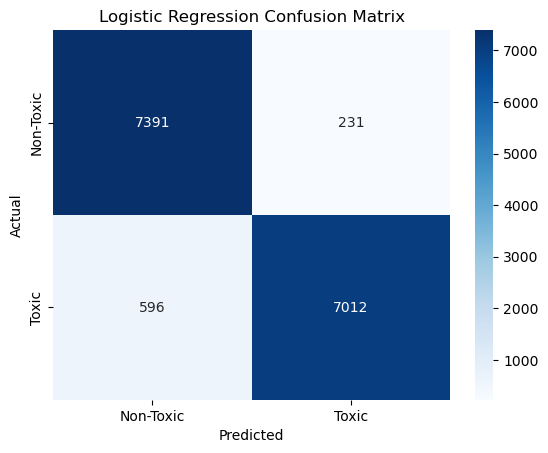


Random Forest Classification Report:
              precision    recall  f1-score   support

   Non-Toxic       0.98      0.98      0.98      7622
       Toxic       0.98      0.98      0.98      7608

    accuracy                           0.98     15230
   macro avg       0.98      0.98      0.98     15230
weighted avg       0.98      0.98      0.98     15230



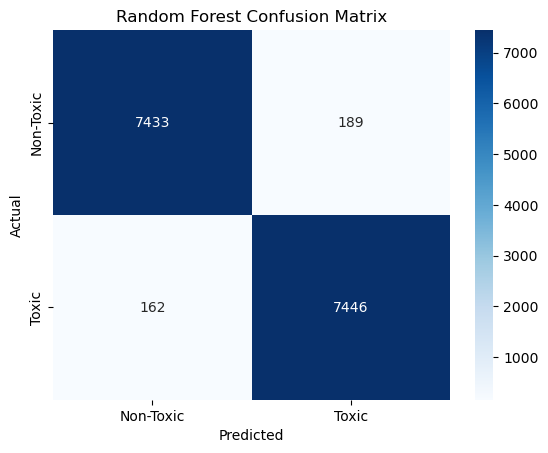

In [3]:
# modeling
from sklearn.ensemble import RandomForestClassifier


models = {
    "Naive Bayes": MultinomialNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='linear', random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}


f1_results = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Non-Toxic', 'Toxic']))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Toxic', 'Toxic'], yticklabels=['Non-Toxic', 'Toxic'])
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    f1_results[name] = f1_score(y_test, y_pred, average='weighted')

/var/folders/km/k5pmmgjj24s61503c875yqnr0000gn/T/ipykernel_44950/2565825761.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(f1_results.keys()), y=list(f1_results.values()), palette='viridis')


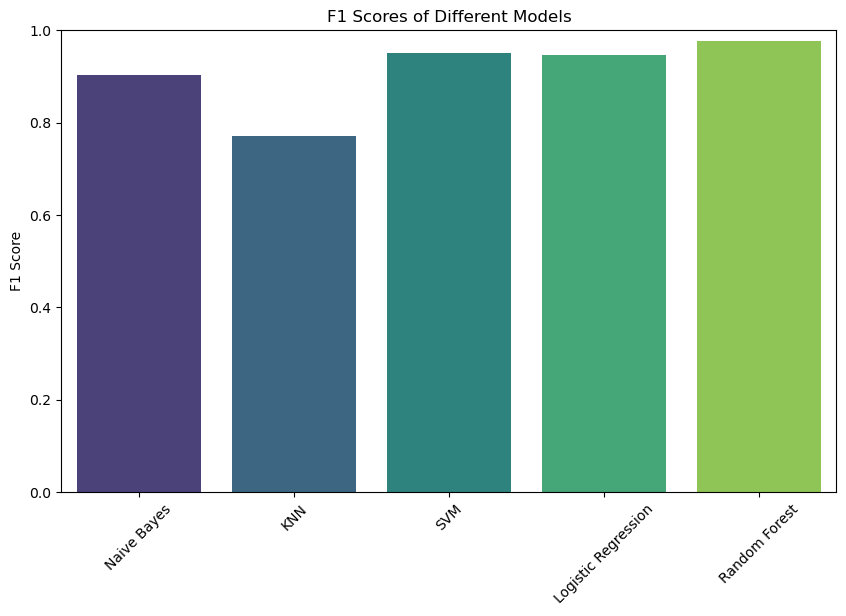

In [4]:
# Plot F1 scores
plt.figure(figsize=(10, 6))
sns.barplot(x=list(f1_results.keys()), y=list(f1_results.values()), palette='viridis')
plt.title('F1 Scores of Different Models')
plt.ylabel('F1 Score')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

/var/folders/km/k5pmmgjj24s61503c875yqnr0000gn/T/ipykernel_44950/802171915.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='viridis')


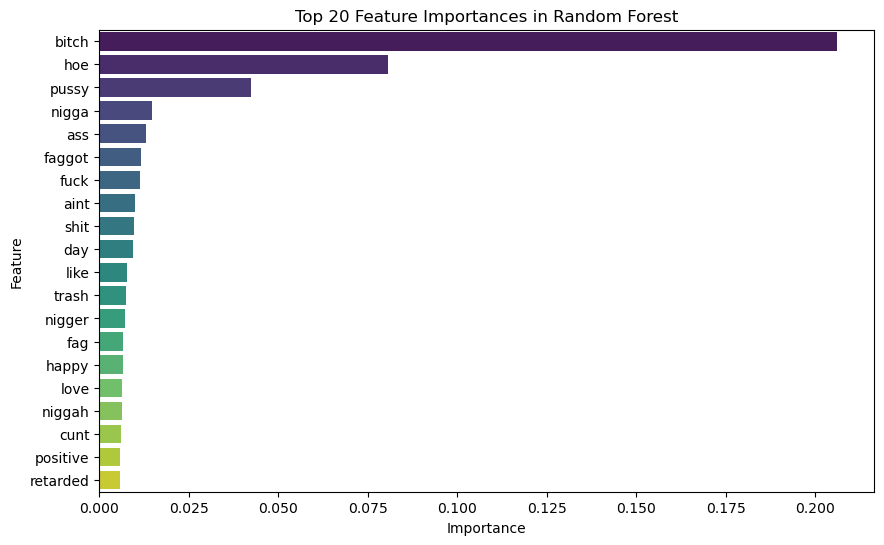

In [5]:
# why is random forest the best? what is the feature importance?
rf_model = models["Random Forest"]
feature_importances = rf_model.feature_importances_
feature_names = vectorizer.get_feature_names_out()
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False).head(20)
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='viridis')
plt.title('Top 20 Feature Importances in Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [6]:
# random forest is the best because it can capture non-linear relationships and interactions between features, which is common in text data. It also reduces overfitting by averaging multiple decision trees, making it more robust to noise in the data.